Today's topics:
* `object`, `attribute`, `method`
* `dir()` and `help()` -- finding what any object can do
* `groupby` and method chaining

> HW6: method-discovery and method-chaining problems

# You've been doing this all along

*`df.describe()` -- what *is* `df`, grammatically? What is `.describe`?*

* **object** -- data bundled with the operations that make sense on it (`str`, `list`, `array`,
  `DataFrame`)
* **attribute** -- data stored *on* the object, no parentheses (`arr.shape`, `df.columns`)
* **method** -- a function belonging to an object, called with parentheses (`arr.mean()`,
  `df.head()`)

`len(x)` takes its argument from outside. `x.method()` is called *on* the object -- it already
knows about `x`.

# Finding what an object can do: `dir()` and `help()`

In [1]:
name = 'Iron'
dir(name)

['__add__',
 '__class__',
 '__contains__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getnewargs__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmod__',
 '__rmul__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'capitalize',
 'casefold',
 'center',
 'count',
 'encode',
 'endswith',
 'expandtabs',
 'find',
 'format',
 'format_map',
 'index',
 'isalnum',
 'isalpha',
 'isascii',
 'isdecimal',
 'isdigit',
 'isidentifier',
 'islower',
 'isnumeric',
 'isprintable',
 'isspace',
 'istitle',
 'isupper',
 'join',
 'ljust',
 'lower',
 'lstrip',
 'maketrans',
 'partition',
 'removeprefix',
 'removesuffix',
 'replace',
 'rfind',
 'rindex',
 'rjust',
 'rpartition',
 'rsplit',
 'rstrip',
 'split',
 'splitlines',
 'startswith',
 'stri

Filter out `__`-prefixed internals (same idiom as Lecture 7's `dir(my_list)`):

In [2]:
[m for m in dir(name) if not m.startswith('__')]

['capitalize',
 'casefold',
 'center',
 'count',
 'encode',
 'endswith',
 'expandtabs',
 'find',
 'format',
 'format_map',
 'index',
 'isalnum',
 'isalpha',
 'isascii',
 'isdecimal',
 'isdigit',
 'isidentifier',
 'islower',
 'isnumeric',
 'isprintable',
 'isspace',
 'istitle',
 'isupper',
 'join',
 'ljust',
 'lower',
 'lstrip',
 'maketrans',
 'partition',
 'removeprefix',
 'removesuffix',
 'replace',
 'rfind',
 'rindex',
 'rjust',
 'rpartition',
 'rsplit',
 'rstrip',
 'split',
 'splitlines',
 'startswith',
 'strip',
 'swapcase',
 'title',
 'translate',
 'upper',
 'zfill']

In [3]:
help(name.title)

Help on built-in function title:

title() method of builtins.str instance
    Return a version of the string where each word is titlecased.

    More specifically, words start with uppercased characters and all remaining
    cased characters have lower case.



In [4]:
name.title()

'Iron'

In [5]:
'  extra spaces  '.strip()

'extra spaces'

You don't need to memorize methods -- you need to know how to ask.

In [6]:
my_list = [3, 1, 4, 1, 5]
[m for m in dir(my_list) if not m.startswith('__')]

['append',
 'clear',
 'copy',
 'count',
 'extend',
 'index',
 'insert',
 'pop',
 'remove',
 'reverse',
 'sort']

In [7]:
help(my_list.count)

Help on built-in function count:

count(value, /) method of builtins.list instance
    Return number of occurrences of value.



In [8]:
my_list.count(1)

2

Works on *any* object, including ones you haven't seen yet -- including scipy results in a few
weeks.

# Attributes vs. methods, side by side

In [9]:
import numpy as np

hardness = np.array([210, 225, 198, 240, 215, 230])

Attributes -- no parentheses:

In [10]:
hardness.shape

(6,)

In [11]:
hardness.dtype

dtype('int64')

In [12]:
hardness.size

6

Methods -- parentheses:

In [13]:
hardness.mean()

np.float64(219.66666666666666)

In [14]:
hardness.std()

np.float64(13.743685418725535)

In [15]:
hardness.argmax()

np.int64(3)

*Watch closely:*

In [16]:
print(hardness)
hardness.sort()
print(hardness)

[210 225 198 240 215 230]
[198 210 215 225 230 240]


`.sort()` sorted **in place** and returned `None`. `.mean()` returns a new value, leaves
`hardness` untouched. Some methods hand back an answer; some mutate the object. `help()` tells
you which.

# A DataFrame is an object too -- meet the steels data

## Dataset: Steel Alloy Compositions and Mechanical Properties

This dataset contains elemental compositions and mechanical properties of 915 steel alloys.

Composition columns (in wt%): `C`, `Si`, `Mn`, `P`, `S`, `Ni`, `Cr`, `Mo`, `Cu`, `V`, `Al`, `N`, `Ceq`, `Nb + Ta`

Target columns: `0.2% Proof Stress (MPa)`, `Tensile Strength (MPa)`, `Elongation (%)`, `Reduction in Area (%)`

The `Alloy code` column contains labels like `A1`, `B3`, etc. We derive `alloy_family` (first letter only)
to get a small set of categorical labels useful for classification tasks (4 families: C, L, M, V, all >150 samples).

In [17]:
import os
import pandas as pd

_file = 'steels.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

try:
    data = pd.read_csv(_local if _local else _github)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

# derive alloy family label (first letter of alloy code)
data['Alloy family'] = [c[0] for c in data['Alloy code']]

# set up features (composition columns) and target
x = data.loc[:, ' C':'Nb + Ta']
y = data['Alloy family']
alloy_family = data['Alloy family']

print(f'{len(data)} samples, {x.shape[1]} composition features')
data.head()

915 samples, 14 composition features


,Alloy code,C,Si,Mn,P,S,Ni,Cr,Mo,Cu,...,Al,N,Ceq,Nb + Ta,Temperature (°C),0.2% Proof Stress (MPa),Tensile Strength (MPa),Elongation (%),Reduction in Area (%),Alloy family
0,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,27,342,490,30,71,M
1,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,100,338,454,27,72,M
2,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,200,337,465,23,69,M
3,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,300,346,495,21,70,M
4,MBB,0.12,0.36,0.52,0.009,0.003,0.089,0.97,0.61,0.04,...,0.003,0.0066,0.0,0.0,400,316,489,26,79,M


### Why this one?

Steel is the workhorse structural material of modern engineering, and its properties
are famously tunable by small changes in alloying element content. With 915 real
alloys and their measured mechanical properties, this dataset lets students ask the
central materials-science question directly: how does composition (wt% of C, Mn, Cr,
etc.) determine mechanical performance (strength, elongation), and do different alloy
families behave differently?

In [18]:
print(alloy_family.value_counts())
print(data[[' 0.2% Proof Stress (MPa)', ' Tensile Strength (MPa)']].describe())

Alloy family
C    385
M    191
V    180
L    159
Name: count, dtype: int64
       0.2% Proof Stress (MPa)  Tensile Strength (MPa)
count               915.000000              915.000000
mean                328.218579              496.248087
std                 131.653232              239.710650
min                  27.000000              162.000000
25%                 220.000000              413.000000
50%                 290.000000              479.000000
75%                 432.500000              575.000000
max                 690.000000             6661.000000


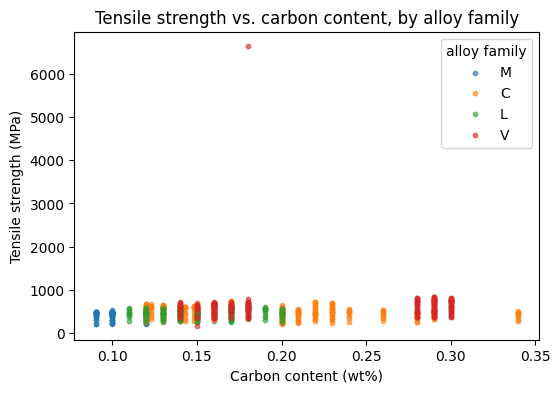

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
for fam in alloy_family.unique():
    mask = alloy_family == fam
    ax.scatter(data.loc[mask, ' C'], data.loc[mask, ' Tensile Strength (MPa)'], s=10, alpha=0.6, label=fam)
ax.set_xlabel('Carbon content (wt%)')
ax.set_ylabel('Tensile strength (MPa)')
ax.legend(title='alloy family')
ax.set_title('Tensile strength vs. carbon content, by alloy family')
plt.show()

Attributes:

In [20]:
data.shape

(915, 21)

In [21]:
data.columns

Index(['Alloy code', ' C', ' Si', ' Mn', ' P', ' S', ' Ni', ' Cr', ' Mo',
       ' Cu', 'V', ' Al', ' N', 'Ceq', 'Nb + Ta', ' Temperature (°C)',
       ' 0.2% Proof Stress (MPa)', ' Tensile Strength (MPa)',
       ' Elongation (%)', ' Reduction in Area (%)', 'Alloy family'],
      dtype='object')

In [22]:
data.dtypes

Alloy code                   object
 C                          float64
 Si                         float64
 Mn                         float64
 P                          float64
 S                          float64
 Ni                         float64
 Cr                         float64
 Mo                         float64
 Cu                         float64
V                           float64
 Al                         float64
 N                          float64
Ceq                         float64
Nb + Ta                     float64
 Temperature (°C)             int64
 0.2% Proof Stress (MPa)      int64
 Tensile Strength (MPa)       int64
 Elongation (%)               int64
 Reduction in Area (%)        int64
Alloy family                 object
dtype: object

Methods:

In [23]:
data.describe()

,C,Si,Mn,P,S,Ni,Cr,Mo,Cu,V,Al,N,Ceq,Nb + Ta,Temperature (°C),0.2% Proof Stress (MPa),Tensile Strength (MPa),Elongation (%),Reduction in Area (%)
count,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000,915.000000
mean,0.174929,0.310918,0.812962,0.014543,0.010602,0.143016,0.427861,0.442870,0.079148,0.060190,0.012435,0.007652,0.093989,0.000041,351.601093,328.218579,496.248087,26.789071,70.206557
std,0.059674,0.086871,0.342775,0.005244,0.004024,0.172746,0.457568,0.394383,0.058481,0.096403,0.013067,0.002321,0.172533,0.000261,189.714773,131.653232,239.710650,8.806595,12.389289
min,0.090000,0.180000,0.420000,0.006000,0.003000,0.000000,0.000000,0.005000,0.000000,0.000000,0.002000,0.002500,0.000000,0.000000,27.000000,27.000000,162.000000,10.000000,18.000000
25%,0.130000,0.240000,0.500000,0.010000,0.008000,0.023000,0.040000,0.050000,0.040000,0.000000,0.004000,0.006200,0.000000,0.000000,200.000000,220.000000,413.000000,20.000000,62.000000
50%,0.160000,0.300000,0.680000,0.014000,0.010000,0.050000,0.110000,0.500000,0.070000,0.000000,0.006000,0.007600,0.000000,0.000000,400.000000,290.000000,479.000000,26.000000,71.000000
75%,0.200000,0.370000,1.210000,0.018000,0.012000,0.210000,1.000000,0.560000,0.110000,0.070000,0.016000,0.009000,0.000000,0.000000,500.000000,432.500000,575.000000,31.000000,80.000000
max,0.340000,0.520000,1.480000,0.030000,0.022000,0.600000,1.310000,1.350000,0.250000,0.300000,0.050000,0.015000,0.437000,0.001700,650.000000,690.000000,6661.000000,78.000000,94.000000


Every number here is a statistic you computed by hand in Module 1 -- now one call, per column.

In [24]:
[m for m in dir(data) if not m.startswith('__')][:20]

['Ceq',
 'T',
 'V',
 '_AXIS_LEN',
 '_AXIS_ORDERS',
 '_AXIS_TO_AXIS_NUMBER',
 '_HANDLED_TYPES',
 '_accessors',
 '_accum_func',
 '_agg_examples_doc',
 '_agg_see_also_doc',
 '_align_for_op',
 '_align_frame',
 '_align_series',
 '_append',
 '_arith_method',
 '_arith_method_with_reindex',
 '_as_manager',
 '_attrs',
 '_box_col_values']

`mean`, `sort_values` -- familiar. `groupby` -- not yet. That's next.

A single column is also an object, not a plain list:

In [25]:
ts = data[' Tensile Strength (MPa)']
type(ts)

pandas.core.series.Series

In [26]:
ts.mean(), ts.max()

(np.float64(496.248087431694), np.int64(6661))

A `Series` has its own methods -- `.mean()`, `.max()`, `.describe()` all work on it too.

# `groupby`: the payoff

*915 alloys, a handful of families -- do they behave differently, on average?*

In [27]:
data.groupby('Alloy family')

`DataFrameGroupBy object` -- not helpful alone. Same move as always: `dir()` it, or call a
method.

In [28]:
data.groupby('Alloy family').mean(numeric_only=True)

,C,Si,Mn,P,S,Ni,Cr,Mo,Cu,V,Al,N,Ceq,Nb + Ta,Temperature (°C),0.2% Proof Stress (MPa),Tensile Strength (MPa),Elongation (%),Reduction in Area (%)
Alloy family,,,,,,,,,,,,,,,,,,,
C,0.186338,0.313948,1.031481,0.017135,0.011156,0.113325,0.070190,0.062068,0.067299,0.027205,0.020605,0.006720,0.223377,0.000097,333.714286,321.846753,488.272727,29.033766,70.966234
L,0.153774,0.296792,0.824025,0.011321,0.009667,0.196792,0.052516,0.522516,0.088365,0.000000,0.008698,0.006858,0.000000,0.000000,349.427673,288.157233,455.924528,27.477987,69.584906
M,0.119738,0.297539,0.466597,0.013770,0.009890,0.040524,0.844607,0.524869,0.055288,0.000000,0.006555,0.008765,0.000000,0.000000,364.869110,234.942408,425.963351,29.895288,75.130890
V,0.227778,0.331111,0.703333,0.012667,0.011000,0.267778,1.082222,1.100000,0.121667,0.247778,0.004500,0.009167,0.000000,0.000000,377.700000,476.211111,623.505556,18.083333,63.905556


One row per family. Narrow to one column:

In [29]:
data.groupby('Alloy family')[' Elongation (%)'].mean()

Alloy family
C    29.033766
L    27.477987
M    29.895288
V    18.083333
Name:  Elongation (%), dtype: float64

`.describe()` still works, now per group:

In [30]:
data.groupby('Alloy family').describe()

C                                                       Si  \
              count      mean       std   min   25%   50%   75%   max  count   
Alloy family                                                                   
C             385.0  0.186338  0.054366  0.12  0.14  0.17  0.22  0.34  385.0   
L             159.0  0.153774  0.024461  0.11  0.14  0.15  0.17  0.20  159.0   
M             191.0  0.119738  0.020038  0.09  0.10  0.12  0.12  0.16  191.0   
V             180.0  0.227778  0.064432  0.14  0.16  0.23  0.29  0.30  180.0   

                        ... Elongation (%)       Reduction in Area (%)  \
                  mean  ...            75%   max                 count   
Alloy family            ...                                              
C             0.313948  ...           33.0  61.0                 385.0   
L             0.296792  ...           30.0  49.0                 159.0   
M             0.297539  ...           32.5  78.0                 191.0   
V             0.331111  ...           19.0  37.0                 180.0   

                                                                   
                   mean        std   min   25%   50%    75%   max  
Alloy family                                                       
C             70.966234  10.713912  43.0  64.0  71.0  79.00  91.0  
L             69.584906  12.307403  28.0  63.5  70.0  80.00  92.0  
M             75.130890  10.022009  49.0  69.0  76.0  82.50  94.0  
V             63.905556  15.159744  18.0  54.0  62.0  75.25  93.0  

[4 rows x 152 columns]

`groupby` just changes what your existing methods operate on. (Comparing groups with a real
yes-or-no answer -- that's hypothesis testing, later in the course.)

> **Read more:** [PDSH — Introducing Pandas Objects](https://jakevdp.github.io/PythonDataScienceHandbook/03.01-introducing-pandas-objects.html), [W3Schools — Python Classes/Objects](https://www.w3schools.com/python/python_classes.asp)

### [Check your understanding]

* Use `dir()`/`help()` to find a `Series` method you haven't used yet
* Try it on `data[' Tensile Strength (MPa)']`
* Is it an attribute (no parens) or a method (parens)? Does it return a value or mutate?

# Method chaining

`data.groupby(...).mean()` -- do this, then that to the result. Each result is itself an object.

In [31]:
data.groupby('Alloy family')[' Tensile Strength (MPa)'].mean()

Alloy family
C    488.272727
L    455.924528
M    425.963351
V    623.505556
Name:  Tensile Strength (MPa), dtype: float64

In [32]:
(data.groupby('Alloy family')[' Tensile Strength (MPa)']
     .mean()
     .sort_values(ascending=False))

Alloy family
V    623.505556
C    488.272727
L    455.924528
M    425.963351
Name:  Tensile Strength (MPa), dtype: float64

Group, select, average, sort -- read off the last line: which family wins?

Not Pandas-only:

In [33]:
'  Iron Alloy  '.strip().lower().replace(' ', '_')

'iron_alloy'

Long chains: parenthesize and break across lines, not one 200-character line.

### [Check your understanding]

* Write one method chain on `data` answering: which alloy family has the lowest average
  reduction in area? (column: `' Reduction in Area (%)'`)

# Preview: scipy result objects

In a few weeks, `scipy.optimize.curve_fit(...)` hands back an object, not a plain number.

In [34]:
from scipy import stats

result = stats.linregress(data[' 0.2% Proof Stress (MPa)'], data[' Tensile Strength (MPa)'])
result

LinregressResult(slope=np.float64(0.8746617614256543), intercept=np.float64(209.1678467854071), rvalue=np.float64(0.48037935911814245), pvalue=np.float64(5.303425350967143e-54), stderr=np.float64(0.05285062418832119), intercept_stderr=np.float64(18.688586532346985))

In [35]:
result.slope, result.intercept, result.rvalue

(np.float64(0.8746617614256543),
 np.float64(209.1678467854071),
 np.float64(0.48037935911814245))

`.slope`, `.intercept`, `.rvalue` sit on it as attributes -- exactly like `hardness.shape`.

Next class: everything from this module together -- arrays, stats, Pandas, plotting, filtering,
loops, functions, objects -- before Midterm 1.

## Further reading

- [w3schools: Python classes and objects](https://www.w3schools.com/python/python_classes.asp)